In [147]:
import pandas as pd
import os
import numpy as np
import pathlib
import glob

import matplotlib.pyplot as plt
import seaborn as sns

Truputis duomenų iš suvestinės užrašų knygelėje

In [121]:
hpc_summary = pd.DataFrame({
    'JOBID': [214457, 214459, 214463, 214465, 214472, 214473, 214477, 214487],
    'Cores': np.repeat(12, 8),
    'DataLink': ['87/90', 365, 366, 365, 365, 365, 366, 365],
    'Year': range(2026, 2018, -1),
    'Duration (s)': [484.93, 2002.68, np.nan, np.nan, np.nan, 2099.58, 2099.04, 2087.17]
})

hpc_summary

,JOBID,Cores,DataLink,Year,Duration (s)
0,214457,12,87/90,2026,484.93
1,214459,12,365,2025,2002.68
2,214463,12,366,2024,NaN
3,214465,12,365,2023,NaN
4,214472,12,365,2022,NaN
5,214473,12,365,2021,2099.58
6,214477,12,366,2020,2099.04
7,214487,12,365,2019,2087.17


In [122]:
hpc_summary = hpc_summary.replace(np.nan, hpc_summary['Duration (s)'][1:].mean(skipna=True))

total_seconds = hpc_summary['Duration (s)'].sum()
hours, remainder = divmod(total_seconds, 3600)
minutes = remainder / 60
seconds = int(total_seconds / 60 - minutes)

print(f"Bendra METOP-B duomenų siuntimo trukmė: {hours:.0f} val. {minutes:.0f} min.")

Bendra METOP-B duomenų siuntimo trukmė: 4 val. 10 min.


**PRIMINIMAS: Neleisti viso Note Book!**

### Neapjungtų metų sujungimas

In [ ]:
path = "C:\\Users\\crist\\Downloads\\Processed_files_2021\\"
# path_pattern = r"C:\Users\crist\Downloads\Processed_files_2021\*2021*.csv"

csv_files = os.listdir(path = path)
# csv_files = glob.glob(path_pattern)

print(csv_files[:6]); print(len(csv_files))

['C:\\Users\\crist\\Downloads\\Processed_files_2021\\gome2b_offline_2021_01_01.csv', 'C:\\Users\\crist\\Downloads\\Processed_files_2021\\gome2b_offline_2021_01_02.csv', 'C:\\Users\\crist\\Downloads\\Processed_files_2021\\gome2b_offline_2021_01_03.csv', 'C:\\Users\\crist\\Downloads\\Processed_files_2021\\gome2b_offline_2021_01_04.csv', 'C:\\Users\\crist\\Downloads\\Processed_files_2021\\gome2b_offline_2021_01_05.csv', 'C:\\Users\\crist\\Downloads\\Processed_files_2021\\gome2b_offline_2021_01_06.csv']
365


In [ ]:
def conect(name, path = path):
    return os.path.join(path, name)

df = pd.concat([
    pd.read_csv(conect(f)) for f in csv_files 
    if os.path.exists(conect(f)) and os.path.getsize(conect(f)) > 1
])

# df = pd.concat([pd.read_csv(f) for f in csv_files
#                 if os.path.getsize(f) > 1], ignore_index=True)

In [63]:
df.head()

,BrO,BrO_Error,H2O,H2O_Error,HCHO,HCHO_Error,NO2,NO2Tropo,NO2Tropo_Error,NO2_Error,O3,O3_Error,SO2,SO2_Error,lat,lon,date
0,3.828157e+13,6.629840e+12,-1.0,-1.0,-1.0,-1.0,8.266425e+14,-1.0,-1.0,8.954492e+13,331.93628,3.111013,-0.476628,0.549171,59.300743,30.291668,2021-01-01
1,4.335799e+13,6.557943e+12,-1.0,-1.0,-1.0,-1.0,7.355490e+14,-1.0,-1.0,8.751005e+13,328.27620,2.985733,0.020478,0.017398,58.966050,30.034346,2021-01-01
2,3.372352e+13,6.441683e+12,-1.0,-1.0,-1.0,-1.0,8.187706e+14,-1.0,-1.0,9.597959e+13,333.31754,2.849227,-1.933218,8.109867,58.632584,29.773224,2021-01-01
3,3.427158e+13,6.443528e+12,-1.0,-1.0,-1.0,-1.0,7.996469e+14,-1.0,-1.0,8.354553e+13,328.38266,3.056865,-0.139363,0.145830,58.295345,29.533236,2021-01-01
4,4.447117e+13,6.805432e+12,-1.0,-1.0,-1.0,-1.0,9.767299e+14,-1.0,-1.0,8.909331e+13,351.67694,3.304269,-0.852744,1.203110,59.163258,24.297420,2021-01-01


In [64]:
downloads_dir_path = 'C:\\Users\\crist\\Downloads'

df.to_csv(os.path.join(downloads_dir_path, "GOME2B_DATA_2021.csv"), index=False)

---
### Bendras sujungimas

In [123]:
csv_files = os.listdir(os.path.join(downloads_dir_path, 'ready GOME2'))
csv_files

['GOME2B_DATA_2019.csv',
 'GOME2B_DATA_2020.csv',
 'GOME2B_DATA_2021.csv',
 'GOME2B_DATA_2022.csv',
 'GOME2B_DATA_2023_2024.csv',
 'GOME2B_DATA_2025.csv',
 'GOME2B_DATA_2026.csv']

In [124]:
final_df = pd.concat(pd.read_csv(os.path.join(downloads_dir_path, 'ready GOME2', f)) for f in csv_files)

In [125]:
final_df.shape

(1770813, 17)

In [126]:
final_df.replace(-1, np.nan)

,BrO,BrO_Error,H2O,H2O_Error,HCHO,HCHO_Error,NO2,NO2Tropo,NO2Tropo_Error,NO2_Error,O3,O3_Error,SO2,SO2_Error,lat,lon,date
0,3.681486e+13,1.175837e+13,NaN,NaN,NaN,NaN,2.627140e+15,NaN,NaN,2.160325e+14,314.89392,1.179834,-1.787203,1.012675,59.242374,23.354510,2019-10-15
1,4.967117e+13,1.274332e+13,NaN,NaN,NaN,NaN,2.258971e+15,NaN,NaN,1.882718e+14,313.45496,1.304120,0.984330,1.308211,59.201694,22.274109,2019-10-15
2,4.211021e+13,1.301123e+13,NaN,NaN,NaN,NaN,2.431526e+15,NaN,NaN,1.710009e+14,314.57776,1.355799,-1.942591,1.025368,58.943607,22.959288,2019-10-15
3,4.537575e+13,1.197143e+13,NaN,NaN,NaN,NaN,2.342994e+15,NaN,NaN,1.708479e+14,315.24316,1.345794,-0.303985,0.414041,59.309425,21.843498,2019-10-15
4,4.300306e+13,1.261190e+13,NaN,NaN,NaN,NaN,2.336728e+15,NaN,NaN,1.832586e+14,309.98590,1.313012,0.010271,0.031225,58.903000,21.879187,2019-10-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55780,5.155735e+13,1.438464e+13,NaN,NaN,NaN,NaN,1.595460e+15,1.801431e+15,1.970735e+15,1.675795e+14,428.50107,1.416726,-2.002236,8.607211,51.496574,19.091486,2026-02-08
55781,2.486765e+13,1.266010e+13,NaN,NaN,NaN,NaN,1.294561e+15,NaN,NaN,1.633897e+14,418.97104,1.726417,1.466866,2.582030,51.438680,16.580502,2026-02-08
55782,3.394596e+13,1.306851e+13,NaN,NaN,NaN,NaN,1.351132e+15,NaN,NaN,1.369905e+14,408.08258,1.836776,3.388359,3.552766,51.520470,15.440484,2026-02-08
55783,3.157099e+13,1.391171e+13,NaN,NaN,NaN,NaN,1.415115e+15,NaN,NaN,1.493191e+14,413.03372,2.058753,-18.999784,12.233781,51.590767,14.308120,2026-02-08


---
### Truputis statistikos

In [130]:
final_df = final_df.reset_index()

$$a = \sin^2\left(\frac{\Delta \phi}{2}\right) + \cos \phi_1 \cdot \cos \phi_2 \cdot \sin^2\left(\frac{\Delta \lambda}{2}\right)$$

$$c = 2 \cdot \operatorname{atan2}(\sqrt{a}, \sqrt{1-a})$$

$$d = R \cdot c$$

[Wikipedia: Haversine formula](https://en.wikipedia.org/wiki/Haversine_formula#:~:text=Either%20formula%20is%20only%20an%20approximation%20when,other%20formulas%20in%20the%20geographical%20distance%20article.)

In [134]:
Vilnius = (54.6872, 25.2797)

def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlambda/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

final_df["km_to_Vilnius"] = haversine_vectorized(
    final_df['lat'], final_df['lon'], 
    Vilnius[0], Vilnius[1]
)

In [ ]:
min_dist_df = final_df.groupby('date')['km_to_Vilnius'].min()
print(f"Atstumų didesnių nei 50 km nuo Vilniaus skaičius: {int(min_dist_df[min_dist_df > 50].count())}")

Atstumų didesnių nei 50 km nuo Vilniaus skaičius: 14


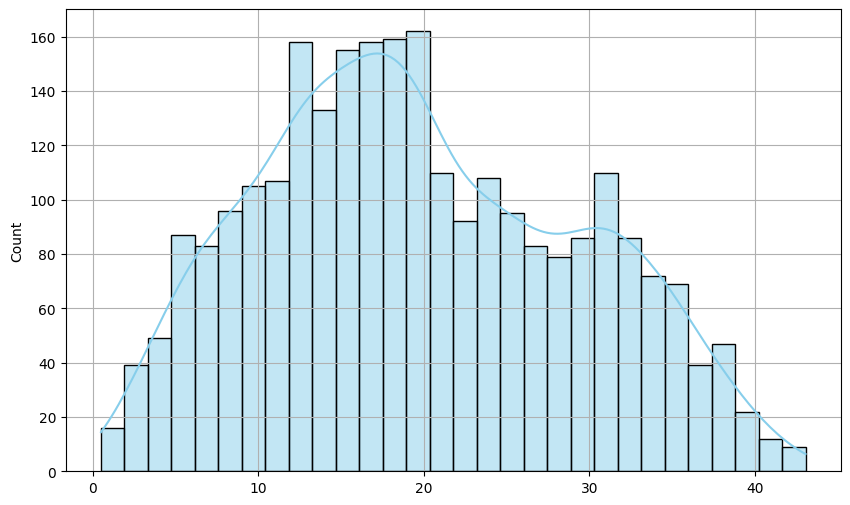

In [166]:
plt.figure(figsize=(10, 6))
sns.histplot(min_dist_df.values[min_dist_df.values < 50], kde=True, color='skyblue', bins=30)
plt.grid()
plt.show()